In [16]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [17]:
# TensorFlow / Keras functions
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [18]:
#Download and fetch the data using the following Python code (Note: We will use faces.images for X).

# Load the data
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
X = faces.images
y = faces.target.reshape(-1, 1)

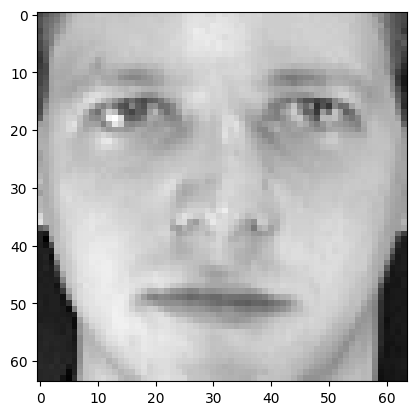

In [19]:
# Selecting an image
image = X[0]  # choose the first image in the dataset

# Display the image
plt.imshow(image, cmap=plt.cm.gray)
plt.show()

In [20]:
# Creating the training and testing sets

X_train_list = []
X_test_list = []
y_train_list = []
y_test_list = []

y_flat = faces.target  # shape (400,)

for person_id in np.unique(y_flat):
    # Get all images for this person
    idx = np.where(y_flat == person_id)[0]
    
    # Split first 5 for training, last 5 for testing
    X_train_list.append(X[idx[:5]])
    X_test_list.append(X[idx[5:]])
    
    y_train_list.append(y_flat[idx[:5]])
    y_test_list.append(y_flat[idx[5:]])

# Combine all persons into final arrays
X_train = np.concatenate(X_train_list)
X_test = np.concatenate(X_test_list)
y_train = np.concatenate(y_train_list)
y_test = np.concatenate(y_test_list)

# Print dimensions
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (200, 64, 64)
X_test shape: (200, 64, 64)
y_train shape: (200,)
y_test shape: (200,)


In [21]:
# Conversion
# Convert labels to one-hot encoded format (40 classes)
y_train_onehot = to_categorical(y_train, num_classes=40)
y_test_onehot = to_categorical(y_test, num_classes=40)

# Print dimensions
print("y_train_onehot shape:", y_train_onehot.shape)
print("y_test_onehot shape:", y_test_onehot.shape)

y_train_onehot shape: (200, 40)
y_test_onehot shape: (200, 40)


In [22]:
#Reshape the data to fit the input shape of a CNN (200, 64, 64, 1)
# Reshape images to add channel dimension (1 for grayscale)
X_train_reshaped = X_train.reshape(X_train.shape[0], 64, 64, 1)
X_test_reshaped = X_test.reshape(X_test.shape[0], 64, 64, 1)

# Print new shapes
print("X_train_reshaped shape:", X_train_reshaped.shape)
print("X_test_reshaped shape:", X_test_reshaped.shape)

X_train_reshaped shape: (200, 64, 64, 1)
X_test_reshaped shape: (200, 64, 64, 1)


In [23]:
#Lab 3 Part 2 Computer Vision Model 1

In [ ]:
# Input layer
input_tensor = Input(shape=(64, 64, 1))

# 1 Convolutional layer
x = Conv2D(
    filters=16,
    kernel_size=(3, 3),
    strides=(1, 1),
    activation='relu',
    padding='same'
)(input_tensor)

# 1 Max pooling layer
x = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding='valid'
)(x)

# Flatten before dense layer
x = Flatten()(x)

# Fully connected output layer
output_tensor = Dense(40, activation='softmax')(x)

# Define model
model = Model(inputs=input_tensor, outputs=output_tensor)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train_reshaped,
    y_train_onehot,
    epochs=20,
    batch_size=10,
    validation_data=(X_test_reshaped, y_test_onehot)
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.0300 - loss: 4.3946 - val_accuracy: 0.0900 - val_loss: 3.7341
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0450 - loss: 3.7098 - val_accuracy: 0.0500 - val_loss: 3.5313
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1850 - loss: 3.4589 - val_accuracy: 0.3700 - val_loss: 3.3165
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5150 - loss: 3.0222 - val_accuracy: 0.5700 - val_loss: 2.9313
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7300 - loss: 2.3809 - val_accuracy: 0.6000 - val_loss: 2.3536
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7350 - loss: 1.7098 - val_accuracy: 0.7450 - val_loss: 1.9394
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9350 - loss: 1.0663 - val_accuracy: 0.7150 - val_loss: 1.5582
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9700 - loss: 0.5807 - val_accuracy: 0.7700 - v

In [ ]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_onehot, verbose=0)

# Print results
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5683906674385071
Test Accuracy: 0.8849999904632568


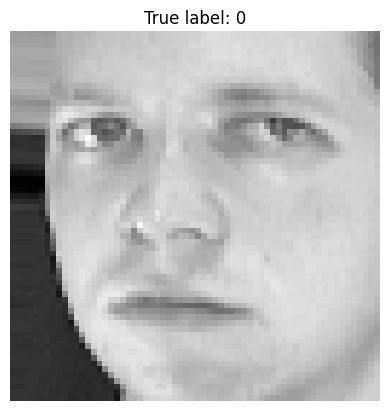

In [ ]:
# Pick one image from the test set
image_index = 0  # you can change this to any index
image = X_test_reshaped[image_index].reshape(64, 64)

# Display the image
plt.imshow(image, cmap=plt.cm.gray)
plt.title(f"True label: {np.argmax(y_test_onehot[image_index])}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step


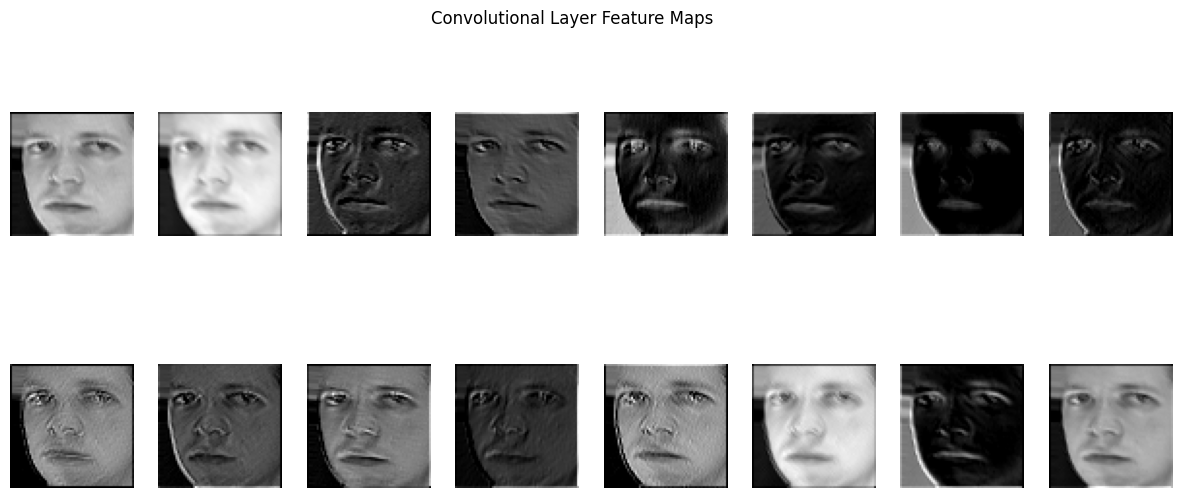

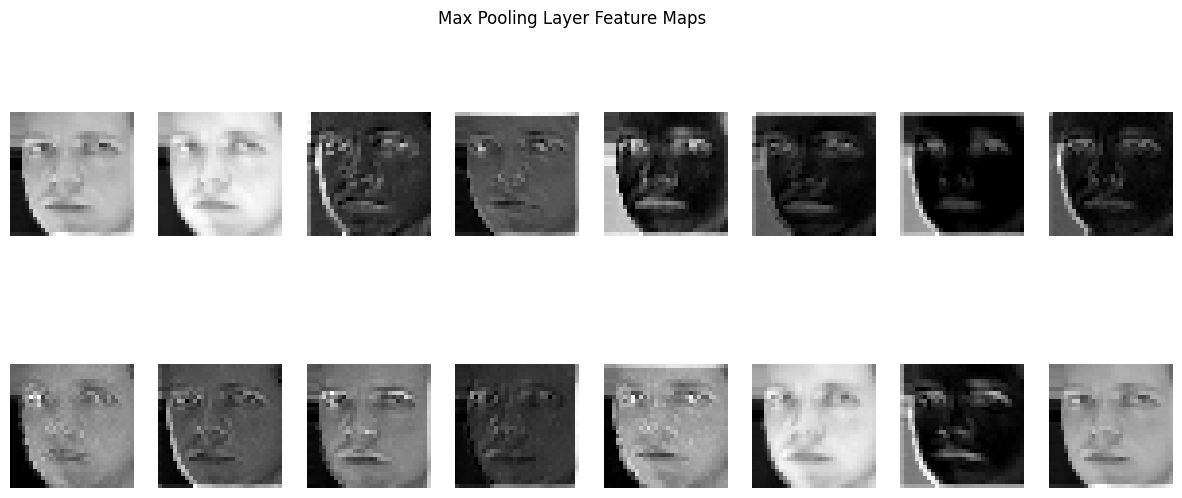

In [ ]:
#Feature Map Visualization
# Model to output activations from Conv and Pool layers
feature_map_model = Model(
    inputs=model.input,
    outputs=[model.layers[1].output, model.layers[2].output]
)
# Select the same test image
image_index = 0
test_image = X_test_reshaped[image_index]

# Add batch dimension
test_image_input = np.expand_dims(test_image, axis=0)

# Get feature maps
conv_features, pool_features = feature_map_model.predict(test_image_input)

# Number of filters = 16
num_filters = conv_features.shape[-1]

# ---- Convolutional feature maps ----
plt.figure(figsize=(15, 6))
for i in range(num_filters):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv_features[0, :, :, i], cmap=plt.cm.gray)
    plt.axis('off')

plt.suptitle("Convolutional Layer Feature Maps")
plt.show()

# ---- Pooling feature maps ----
plt.figure(figsize=(15, 6))
for i in range(num_filters):
    plt.subplot(2, 8, i + 1)
    plt.imshow(pool_features[0, :, :, i], cmap=plt.cm.gray)
    plt.axis('off')

plt.suptitle("Max Pooling Layer Feature Maps")
plt.show()

In [ ]:
# Input layer
input_tensor = Input(shape=(64, 64, 1))

# Convolutional layer (UPDATED window size)
x = Conv2D(
    filters=16,
    kernel_size=(9, 9),   # <-- changed from (3,3) to (9,9)
    strides=(1, 1),
    activation='relu',
    padding='same'
)(input_tensor)

# Max pooling layer
x = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2),
    padding='valid'
)(x)

# Flatten
x = Flatten()(x)

# Output layer
output_tensor = Dense(40, activation='softmax')(x)

# Define model
model2 = Model(inputs=input_tensor, outputs=output_tensor)

# Compile model2
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model2
history2 = model2.fit(
    X_train_reshaped,
    y_train_onehot,
    epochs=20,
    batch_size=10,
    validation_data=(X_test_reshaped, y_test_onehot)
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.0200 - loss: 3.8989 - val_accuracy: 0.1350 - val_loss: 3.6830
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1650 - loss: 3.6762 - val_accuracy: 0.1100 - val_loss: 3.6791
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1000 - loss: 3.6376 - val_accuracy: 0.1700 - val_loss: 3.6325
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1600 - loss: 3.5545 - val_accuracy: 0.0650 - val_loss: 3.5132
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.2900 - loss: 3.3605 - val_accuracy: 0.1600 - val_loss: 3.2832
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4750 - loss: 2.7892 - val_accuracy: 0.5200 - val_loss: 2.6619
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7550 - loss: 2.0364 - val_accuracy: 0.5800 - val_loss: 2.2295
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8350 - loss: 1.4408 - val_accuracy: 0.7300 - v

In [ ]:
# Loss and Accuracy
test_loss, test_accuracy = model2.evaluate(X_test_reshaped, y_test_onehot, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.6023911237716675
Test Accuracy: 0.8600000143051147


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


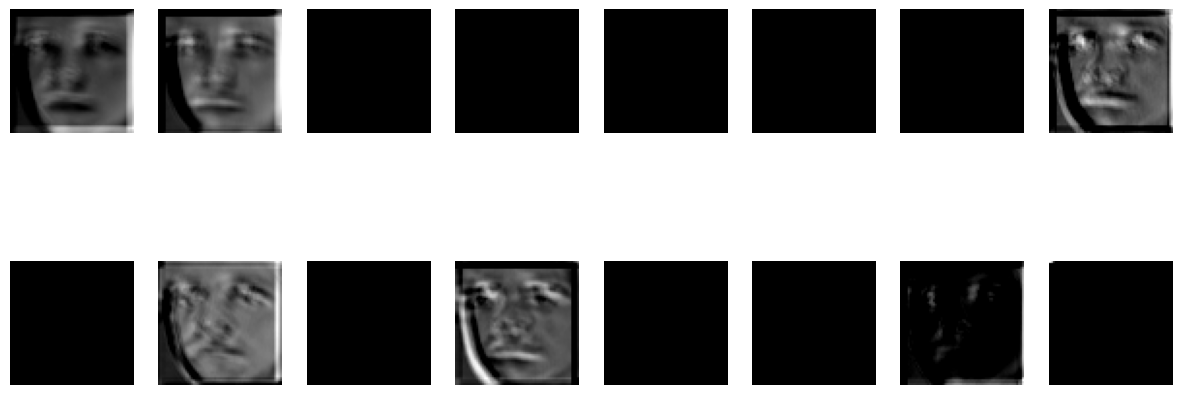

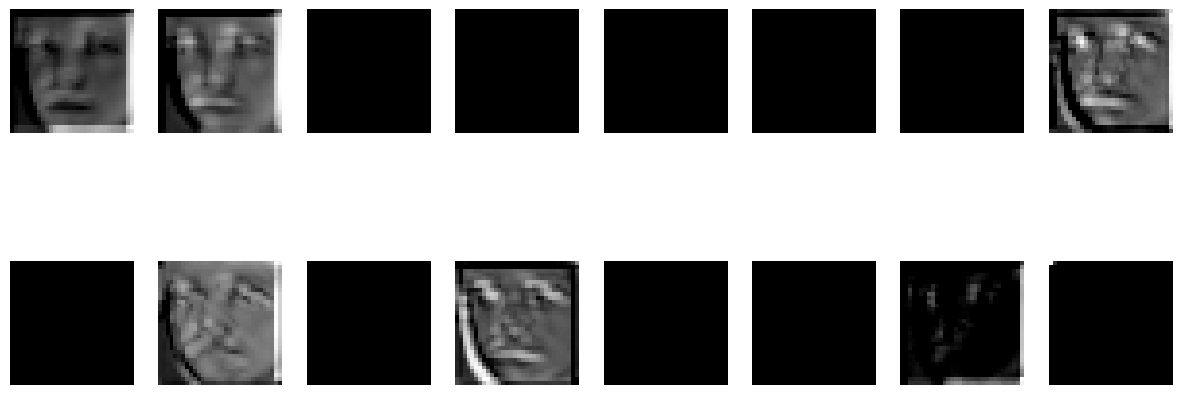

In [ ]:
# Feature maps 

# Create model to get outputs from conv and pooling layers
feature_map_model2 = Model(
    inputs=model2.input,
    outputs=[model2.layers[1].output, model2.layers[2].output]
)

# Use the same image index as before
image_index = 0
test_image = X_test_reshaped[image_index]

# Add batch dimension
test_image_input = np.expand_dims(test_image, axis=0)

# Get feature maps
conv_features, pool_features = feature_map_model2.predict(test_image_input)

# ---- Convolution feature maps ----
plt.figure(figsize=(15, 6))

# For loop 
for i in range(conv_features.shape[-1]):
    plt.subplot(2, 8, i + 1)
    plt.imshow(conv_features[0, :, :, i], cmap=plt.cm.gray)
    plt.axis('off')

plt.show()

# ---- Pooling feature maps ----
plt.figure(figsize=(15, 6))

# For loop 
for i in range(pool_features.shape[-1]):
    plt.subplot(2, 8, i + 1)
    plt.imshow(pool_features[0, :, :, i], cmap=plt.cm.gray)
    plt.axis('off')

plt.show()